# Kapittel 9 - Markedsteori, samfunnsøkonomisk effektivitet



Notatblokken lastes enklest ned på [https://github.com/uit-sok-1303-v26/uit-sok-1303.v26.github.io/blob/main/Markedsteori%20-%20Kapittel%209.ipynb](https://github.com/uit-sok-1303-v26/uit-sok-1303.v26.github.io/blob/main/Markedsteori%20-%20Kapittel%209.ipynb)

## Markedslikevekt ved frikonkurranse





### Markedslikevekt

Vi har et marked med etterspørsel $Q^E$ og tilbud $Q^T$. Likevekten finnes der tilbud og etterspørsel er like:

$$
Q^E(P^*) = Q^T(P^*) \tag{1}
$$

### Eksempel

La etterspørselen være $Q^E = 10 - P$ og tilbudet $Q^T = -2 + P$.

**Likevekt:**

$$
10 - P = -2 + P \tag{2}
$$

$$
12 = 2P \implies P^* = 6 \tag{3}
$$

$$
Q^* = 10 - 6 = 4 \tag{4}
$$

**Konsumentoverskudd (KO):** arealet under etterspørselskurven og over prisen. Invers etterspørsel: $P^D = 10 - Q$.

$$
KO = \int_0^{Q^*}(P^D(Q) - P^*)\,dQ = \int_0^{4}(10 - Q - 6)\,dQ = \int_0^4(4-Q)\,dQ \tag{5}
$$

$$
KO = \left[4Q - \frac{Q^2}{2}\right]_0^4 = 16 - 8 = 8 \tag{6}
$$

**Produsentoverskudd (PO):** arealet over tilbudskurven og under prisen. Invers tilbud: $P^S = 2 + Q$.

$$
PO = \int_0^{Q^*}(P^* - P^S(Q))\,dQ = \int_0^4(6 - 2 - Q)\,dQ = \int_0^4(4-Q)\,dQ = 8 \tag{7}
$$

**Samfunnsøkonomisk overskudd (SO):**

$$
SO = KO + PO = 8 + 8 = 16 \tag{8}
$$

### Dødvektstap

Dersom markedet ikke er i frikonkurranselikevekten for eksempel på grunn av skatt, subsidier, eksternaliteter eller reguleringer oppstår det et **dødvektstap**: et tap av samfunnsøkonomisk overskudd som ingen vinner.




### Eksempel 1


In [124]:
import sympy as sp
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [125]:
P, Q, gamma = sp.symbols('P Q gamma', real=True, positive=True)

def Demand_Q(P):
    return 10 - P

def Supply_Q(P):
    return -2 + P

eq_likevekt = sp.Eq(Demand_Q(P), Supply_Q(P))
P_eq = sp.solve(eq_likevekt, P)[0]
Q_eq = Demand_Q(P_eq)
display(P_eq, Q_eq)


6

4

In [126]:
# Invers etterspørsel og tilbud
inv_demand = sp.solve(sp.Eq(Q, Demand_Q(P)), P)[0]
inv_supply = sp.solve(sp.Eq(Q, Supply_Q(P)), P)[0]

KO = sp.integrate(inv_demand - P_eq, (Q, 0, Q_eq))
PO = sp.integrate(P_eq - inv_supply, (Q, 0, Q_eq))
SO = KO + PO
display(KO, PO, SO)


8

8

16

In [127]:
df = pd.DataFrame({
    'Overskudd': ['Solgt mengde', 'Pris', 'Konsumentoverskudd', 'Produsentoverskudd', 'Samfunnsøkonomisk overskudd'],
    'Verdi (kr)': [np.round(float(Q_eq), 2), 
                   np.round(float(P_eq), 2), 
                   np.round(float(KO), 2),
                   np.round(float(PO), 2),
                   np.round(float(SO), 2)]
})

display(df)

,Overskudd,Verdi (kr)
0,Solgt mengde,4.0
1,Pris,6.0
2,Konsumentoverskudd,8.0
3,Produsentoverskudd,8.0
4,Samfunnsøkonomisk overskudd,16.0


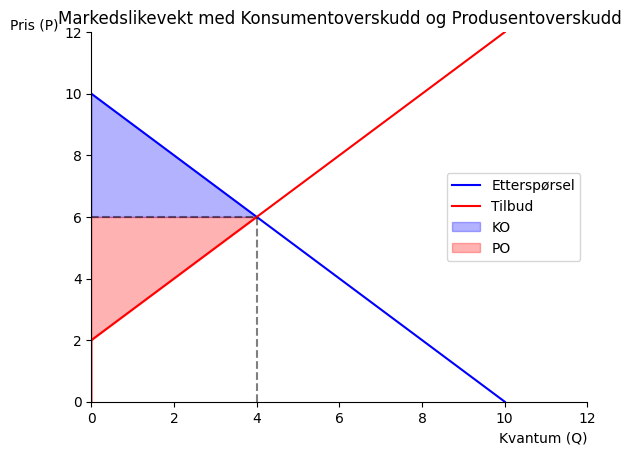

In [128]:
def create_ax():
    fig, ax = plt.subplots()
    ax.set_ylabel('Pris (P)', loc='top', rotation=0)
    ax.set_xlabel('Kvantum (Q)', loc='right')
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
    return fig, ax

P_num = np.linspace(0, 12, 200)
Q_e_fn = sp.lambdify(P, Demand_Q(P))
Q_t_fn = sp.lambdify(P, Supply_Q(P))

fig, ax = create_ax()
ax.plot(Q_e_fn(P_num), P_num, label='Etterspørsel', color='blue')
ax.plot(np.maximum(Q_t_fn(P_num), 0), P_num, label='Tilbud', color='red')

q_fill = np.linspace(0, float(Q_eq), 200)
inv_d_fn = sp.lambdify(Q, inv_demand)
inv_s_fn = sp.lambdify(Q, inv_supply)

ax.fill_between(q_fill, float(P_eq), inv_d_fn(q_fill), alpha=0.3, color='blue', label='KO')
ax.fill_between(q_fill, inv_s_fn(q_fill), float(P_eq), alpha=0.3, color='red', label='PO')
ax.hlines(float(P_eq), 0, float(Q_eq), color='black', linestyle='dashed', alpha=0.5)
ax.vlines(float(Q_eq), 0, float(P_eq), color='black', linestyle='dashed', alpha=0.5)
ax.set(xlim=(0, 12), ylim=(0, 12))
ax.legend()
ax.set_title('Markedslikevekt med Konsumentoverskudd og Produsentoverskudd')
plt.show()


Det samfunnsøkonomiske overskuddet kommer ved å legge sammen "PO" (Produsentoverskudd) og "KO" (Konsumentoverskuddet).

### Eksempel 2
Vi setter opp tilbud og etterspørsel, finner likevekten, og tegner likevekten i en figur. Dette er likevekt under frikonkurranse.

In [129]:
def demand(x):
    return (100 - x)
def supply(x):
    return 20 + x

In [130]:
x=sp.symbols('x', real=True, positive=True)
equ=sp.Eq(demand(x),supply(x))
equ

Eq(100 - x, x + 20)

In [131]:
x_eq=sp.solve(equ,x)
x_eq[0]

40

In [132]:
# Lagrer bare løsningen som et tall
x_eq=float(x_eq[0])
x_eq

40.0

In [133]:
p_eq=demand(x_eq)
p_eq

60.0

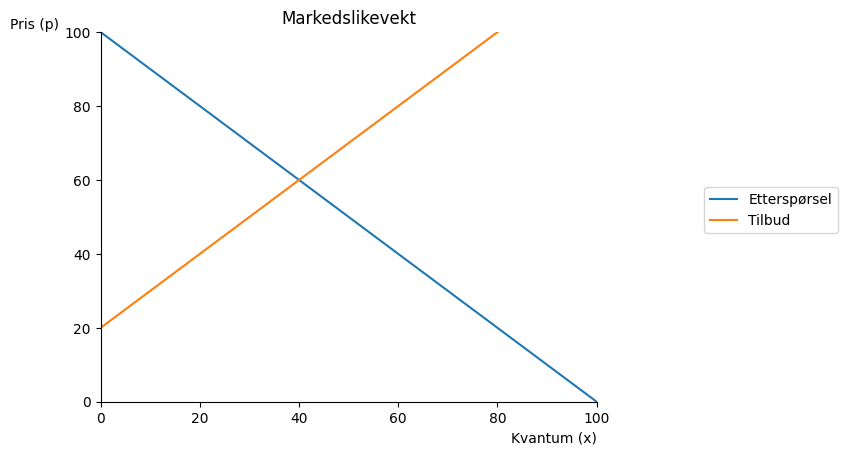

In [134]:
x_num=np.linspace(0.1,100,100)

#lag en akse

def create_ax():
                fig, ax = plt.subplots()
                ax.set_ylabel('Pris (p)', loc='top', rotation = 0)
                ax.set_xlabel('Kvantum (x)', loc='right')
                ax.set(xlim=(0,100))
                ax.set(ylim=(0,100))
                ax.spines['top'].set_color('none')
                ax.spines['right'].set_color('none')
                
                return fig, ax

fig, ax = create_ax()

# plott funksjonen

ax.plot(x_num, demand(x_num), label='Etterspørsel')
ax.plot(x_num, supply(x_num), label='Tilbud')



# tittel
ax.set_title('Markedslikevekt')

#vis navnene:
ax.legend(bbox_to_anchor=(1.5,0.6));

### Vi tegner inn likevektspris og -kvantum.

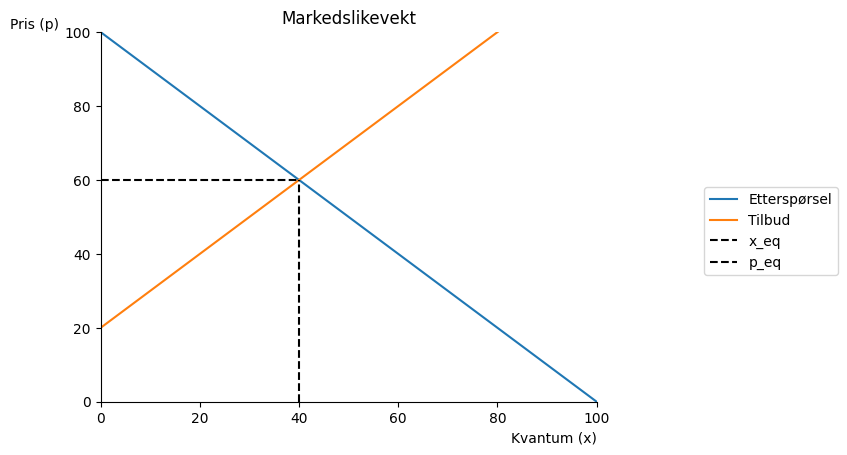

In [135]:
q = np.linspace(0,x_eq,100)

ax.vlines(x_eq,0,demand(x_eq), color='black',ls='dashed', label='x_eq')
ax.hlines(p_eq,0,x_eq, color='black',ls='dashed', label='p_eq')
ax.legend(bbox_to_anchor=(1.5,0.6))
fig


Den vertikale avstanden mellom etterspørselskurven og likevektsprisen er forskjellen i hva konsumenter er villig til å betale for hver ekstra enhet og hva de faktisk må betale. Dette er et overskudd til konsumenten, og kan summeres over alle enheter kjøpt. Dette gir oss konsumentoverskuddet som det grønne området nedenfor.

Den vertikale avstanden mellom likevektsprisen og tilbudskurven viser et overskudd for produsentene ettersom tilbudskurven angir deres grensekostnad. Det røde området i figuren nedenfor angir produsentoverskuddet. Både KO og PO er målt i pengeenheter, og summen utgjør samfunnsøkonomisk overskudd (SO = KO+PO).

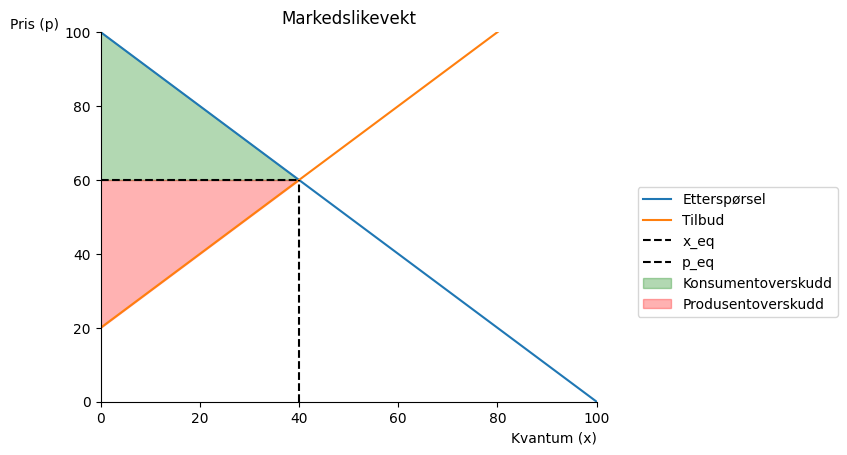

In [136]:
ax.fill_between(q,p_eq,demand(q), color = "green",alpha = 0.3,label='Konsumentoverskudd')
ax.fill_between(q,supply(q),p_eq, color = "red",alpha = 0.3,label='Produsentoverskudd')

ax.legend(bbox_to_anchor=(1.5,0.6))
fig

In [137]:
producer_surplus=sp.integrate(p_eq-supply(x),(x,0,x_eq))
producer_surplus

800.000000000000

In [138]:
consumer_surplus=sp.integrate(demand(x)-p_eq,(x,0,x_eq))
consumer_surplus


800.000000000000

In [139]:
welfare_surplus=float(sp.integrate(demand(x)-supply(x),(x,0,x_eq)))
welfare_surplus

1600.0

In [140]:
import pandas as pd

df = pd.DataFrame({
    'Overskudd': ['Solgt mengde', 'Pris', 'Konsumentoverskudd', 'Produsentoverskudd', 'Samfunnsøkonomisk overskudd'],
    'Verdi (kr)': [np.round(float(x_eq), 2), 
                   np.round(float(p_eq), 2), 
                   np.round(float(consumer_surplus), 2),
                   np.round(float(producer_surplus), 2),
                   np.round(float(welfare_surplus), 2)]
})

display(df)

,Overskudd,Verdi (kr)
0,Solgt mengde,40.0
1,Pris,60.0
2,Konsumentoverskudd,800.0
3,Produsentoverskudd,800.0
4,Samfunnsøkonomisk overskudd,1600.0


## Anbefalt lesestoff rundt norgespris for arbeidskravet

[https://finanspolitikkutvalget.no/2026/02/03/finanspolitikkutvalgets-uttalelse-for-2026/](https://finanspolitikkutvalget.no/2026/02/03/finanspolitikkutvalgets-uttalelse-for-2026/)

## 9.1 Krig på Kontinentet, høyere strømpriser og samfunnsøkonomisk overskudd


Conrad leser i avisen om krigen i Ukraina og at bortfallet av russisk gass har gjort at strømprisen på Kontinentet har gått opp. Han tenker at prisøkningen ikke kan være samfunnsøkonomisk effektivt.

Se for deg en situasjon hvor etterspørselen etter strøm er gitt ved:

$$Q^E = 1 - P$$

Mens tilbudet er gitt ved:

$$Q^T = -\gamma + P$$

Før krigen i Ukraina så var $\gamma_{fred} = 0$, men med stansen av gassleveransene fra Russland, får vi et skift i tilbudskurven, gitt ved $\gamma_{krig} = 0.2$.

**a.** Hva blir likevekten og det samfunnsøkonomiske overskuddet i dette markedet før krigen?




In [141]:
# Definerer symbolene
Q_E, P, Q_T, gamma = sp.symbols('Q_E P Q_T gamma')

# Definerer etterspørsels- og tilbudsfunksjonene
Ettersporsel = sp.Eq(Q_E, 1 - P)
Tilbud = sp.Eq(Q_T, -gamma + P)

display(Ettersporsel, Tilbud)

Eq(Q_E, 1 - P)

Eq(Q_T, P - gamma)

In [142]:
# Løser for likevekt
likevekt = sp.solve(Ettersporsel.rhs - Tilbud.rhs, P)[0]

# Viser likevekten
display(likevekt)

gamma/2 + 1/2

In [143]:
# For fred så har vi gamma = 0
gamma_verdi = 0

P_losning = likevekt.subs(gamma, gamma_verdi)

display(P_losning)

1/2

In [144]:
# Finner likevektskvantum ved å sette likevektsprisen inn i en av funksjonene
Q_losning = Ettersporsel.rhs.subs(P, P_losning)

display(Q_losning)

1/2

In [145]:

# Figurkonfigurasjon
def create_ax():
    fig, ax = plt.subplots()
    ax.set_xlabel('Q', loc = "right")
    ax.set_ylabel('P', rotation=0, loc ='top')
    ax.set_ylim(0, 1.5)
    ax.set_xlim(0, 1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    return fig, ax

### Løsning 9.1 a) med integral – Likevekt og SO før krigen ($\gamma = 0$)

**Setter tilbud lik etterspørsel:**

$$
Q^E = Q^T 
$$

$$
1 - P = 0 + P \implies 1 = 2P 
$$

$$
\boxed{P^*_{fred} = 0.5} 
$$

$$
Q^*_{fred} = 1 - 0.5 = 0.5 
$$

**Invers etterspørsel:** $P^D = 1 - Q$. **Invers tilbud** (med $\gamma=0$): $P^S = Q$.

$$
KO_{fred} = \int_0^{0.5}(1 - Q - 0.5)\,dQ = \int_0^{0.5}(0.5 - Q)\,dQ
$$

$$
KO_{fred} = \left[0.5Q - \frac{Q^2}{2}\right]_0^{0.5} = 0.25 - 0.125 = 0.125 
$$

$$
PO_{fred} = \int_0^{0.5}(0.5 - Q)\,dQ = 0.125
$$

$$
\boxed{SO_{fred} = KO + PO = 0.125 + 0.125 = 0.25} 
$$


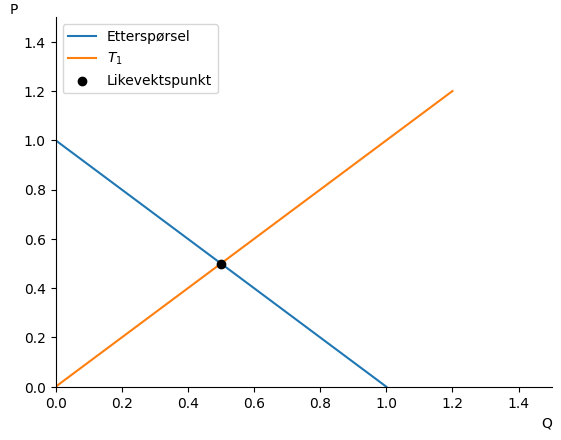

In [146]:
# Viser i figur 9.1a
P_verdier = np.linspace(0, 1.2, 100)

fig, ax = create_ax()

# Etterspørselskurve
ax.plot(1 - P_verdier,P_verdier, label='Etterspørsel')

# Tilbudskurve
ax.plot(-gamma_verdi + P_verdier, P_verdier, label='$T_1$')

# Likevektspunkt fred
ax.scatter(Q_losning, P_losning, color='black', label='Likevektspunkt', zorder=5)

ax.legend();

## Konsumentoverskudd

Konsumentoverskudd er arealet av trekanten mellom etterspørselskurven og prisen, opp til det kvantumet som omsettes i markedet.

For å finne dette må vi huske formelen for areal av trekant, som er:

$$
A = \frac{\text{grunnlinje} \cdot \text{høyde}}{2} 
$$

I vårt tilfelle for å finne konsumentoverskuddet, må vi finne høyden og grunnlinjen til trekanten.

Dette er gitt ved:

$$
g = 0.5
$$


$$
h = 1 - 0.5 = 0.5
$$

Så konsumentoverskuddet blir:

$$
\text{KO} = \frac{0.5 \cdot 0.5}{2} = \frac{0.25}{2} = 0.125
$$



In [147]:
# Konsumentoverskudd, regnet med areal av trekant
KO = (1 - P_losning) * 0.5 / 2

display(KO)

0.125000000000000

## Produsentoverskudd

Produsentoverskudd er arealet av trekanten mellom tilbudskurven og prisen, opp til det kvantumet som omsettes i markedet.

For å finne dette må vi også finne høyden og grunnlinjen til trekanten for produsentoverskudd, dette følger samme formel som for konsumentoverskudd.

Så produsentoverskuddet blir:

$$
\text{PO} = \frac{0.5 \cdot 0.5}{2} = \frac{0.25}{2} = 0.125
$$

## Samfunnsøkonomisk overskudd

Samfunnsøkonomisk overskudd er summen av konsumentoverskudd og produsentoverskudd.

$$
\text{SO} = \text{KO} + \text{PO} = 0.125 + 0.125 = 0.25
$$



In [148]:
# Produsentoverskudd, regnet med areal av trekant
PO = (1- P_losning) * 0.5 / 2

display(PO)

0.125000000000000

In [149]:
# Samfunnsøkonomisk overskudd er summen av konsument- og produsentoverskudd
SO = KO + PO

SO

0.250000000000000

For å tegne dette i python bruker vi funksjonen 'fill_between' for å fylle området mellom kurvene og prisen. Denne bruker integralet av funksjonen for å finne arealet under kurven, og dermed konsument- og produsentoverskuddet.

For å vite hva vi skal 'fylle mellom' eller integrere, så må vi finne invers tilbud og etterspørselskurve.

In [150]:
# Invers tilbud og etterspørselskurve
P_E = sp.solve(Ettersporsel, P)[0]
P_T = sp.solve(Tilbud, P)[0]

display(P_E, P_T)

1 - Q_E

Q_T + gamma

Dette viser bare begge måter å gjøre det på, men for å tegne KO og PO i figuren så må vi bruke fill_between, som bruker integralet for å finne arealet under kurven. Dette må vi også bruke når vi har funksjoner som ikke er lineære, hvor det ikke er like lett å finne høyde og grunnlinje for trekanten. Utregning for å integrere finner dere nederst i notebooken.

In [151]:
# Integrerer for å finne konsument- og produsentoverskudd
KO_integral = sp.integrate(P_E - P_losning, (Q_E, 0, Q_losning))
PO_integral = sp.integrate(P_losning - P_T, (Q_T, 0, Q_losning))

display(float(KO_integral), float(PO_integral.subs(gamma, gamma_verdi)))

0.125

0.125

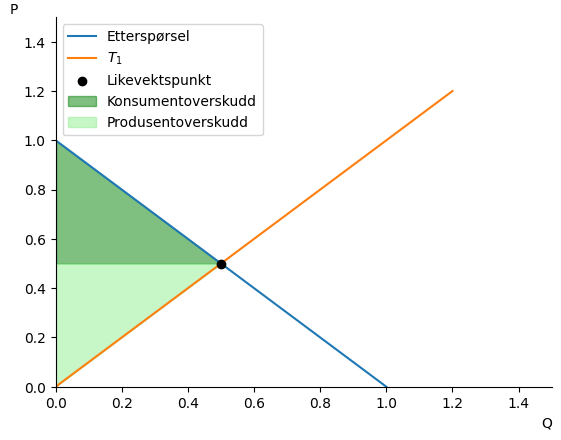

In [152]:
# Vi vet at området som skal fylles går fra 0 til 0.5, derfor må vi definere en liste med Q-verdier som dekker dette området
Q_fyll = np.linspace(0.001, 0.5, 100)

# Konsumentoverskudd, fill_between  fyller området mellom etterspørselskurven og prisen
ax.fill_between(Q_fyll, 1 - Q_fyll, float(P_losning), color='green', alpha=0.5, label='Konsumentoverskudd')

# Prodsentoverskudd, fill_between fyller området mellom tilbudskurven og prisen
ax.fill_between(Q_fyll, Q_fyll + gamma_verdi, float(P_losning), color='lightgreen', alpha=0.5, label='Produsentoverskudd')

ax.legend();
fig

**b.** Hvordan påvirker krigen likevekten og det samfunnsøkonomiske overskuddet? Er du enig med Conrad at det har oppstått et effektivitetstap?


Krig ($\gamma = 0.2$)

**Ny likevekt:**

$$
1 - P = -0.2 + P \implies 1.2 = 2P 
$$

$$
\boxed{P^*_{krig} = 0.6} 
$$

$$
Q^*_{krig} = 1 - 0.6 = 0.4 
$$

**Invers tilbud** (med $\gamma=0.2$): $P^S = Q + 0.2$.

$$
KO_{krig} = \int_0^{0.4}(1 - Q - 0.6)\,dQ = \int_0^{0.4}(0.4 - Q)\,dQ = 0.08 
$$

$$
PO_{krig} = \int_0^{0.4}(0.6 - (Q + 0.2))\,dQ = \int_0^{0.4}(0.4 - Q)\,dQ = 0.08
$$

$$
SO_{krig} = 0.08 + 0.08 = 0.16
$$

**Effektivitetstap** = $SO_{fred} - SO_{krig} = 0.25 - 0.16 = 0.09$.

Conrad har rett: krigen reduserer den samfunnsøkonomiske effektiviteten. Tilbudskurven skifter inn (lavere tilbud), pris stiger, omsatt kvantum faller, og dødvektstapet er $0.09$.

In [153]:
gamma_krig = 0.2

# Substituerer inn krigsverdien for gamma i likevekten for å finne den nye likevektsprisen
P_losning_krig = likevekt.subs(gamma, gamma_krig)

display(P_losning_krig)

0.600000000000000

In [154]:
# Finner likevektskvantum ved å sette likevektsprisen inn i en av funksjonene
Q_losning_krig = Ettersporsel.rhs.subs(P, P_losning_krig)

display(Q_losning_krig)

0.400000000000000

In [155]:
# Konsumentoverskudd under krig, regnet med areal av trekant
KO_krig = (1 - P_losning_krig) * Q_losning_krig / 2

KO_krig

0.0800000000000000

In [156]:
# Produsentoverskudd under krig, regnet med areal av trekant
PO_krig = (1- P_losning_krig) * Q_losning_krig / 2

PO_krig

0.0800000000000000

In [157]:
# Samfunnsøkonomisk overskudd under krig
SO_krig = KO_krig + PO_krig

SO_krig

0.160000000000000

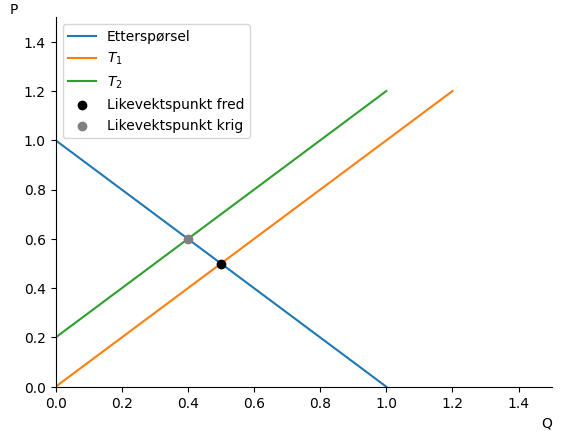

In [158]:
# Figur 9.1b
fig, ax = create_ax()
# Etterspørselskurve fred
ax.plot(1 - P_verdier, P_verdier, label='Etterspørsel')

# Tilbudskurve fred
ax.plot(-gamma_verdi + P_verdier, P_verdier, label='$T_1$')
# Tilbudskurve krig
ax.plot(-gamma_krig + P_verdier, P_verdier, label='$T_2$')

# Likevektspunkt fred
ax.scatter(Q_losning, P_losning, color='black', label='Likevektspunkt fred', zorder=5)
# Likevektspunkt krig
ax.scatter(Q_losning_krig, P_losning_krig, color='grey', label='Likevektspunkt krig', zorder=5)

ax.legend();

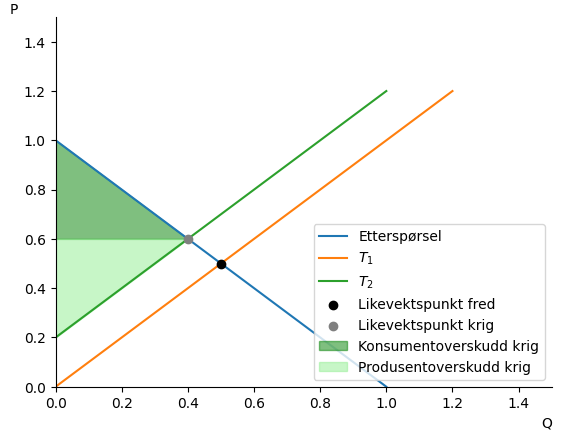

In [159]:
# Fyller inn området for konsumentoverskudd og produsentoverskudd under krig
Q_fyll_krig = np.linspace(0, float(Q_losning_krig), 100)
# Konsumentoverskudd under krig, fill_between  fyller området mellom etterspørselskurven og prisen
ax.fill_between(Q_fyll_krig, 1 - Q_fyll_krig, float(P_losning_krig), color='green', alpha=0.5, label='Konsumentoverskudd krig')
# Prodsentoverskudd under krig, fill_between fyller området mellom tilbudskurven og prisen
ax.fill_between(Q_fyll_krig, Q_fyll_krig + gamma_krig, float(P_losning_krig), color='lightgreen', alpha=0.5, label='Produsentoverskudd krig')
ax.legend();
fig

**c.** Conrad tenker at når krigen er over og vi igjen går tilbake til $\gamma_{fred} = 0$, så vil det samfunnsøkonomiske overskuddet øke, og med det også den samfunnsøkonomiske effektiviteten. Har han rett i det?


Når $\gamma$ går tilbake til $0$ etter krigen, er markedsforholdene identiske med situasjonen i del a). Likevekten og SO returnerer til $P^* = 0.5$, $Q^* = 0.5$, $SO = 0.25$.

Conrad har rett: SO øker tilbake til $0.25$ når krigen er over. Markedet er igjen i den samfunnsøkonomisk effektive likevekten.



## 9.4 Hvorfor skal vi betale så mye for noe vi har så mye av?

Mange synes det er rart at prisen på bensin er så høy i et oljerikt land som Norge. Andre oljerike land har ofte veldig lave bensinpriser, hvorfor ikke også i Norge?

**a.** Begynn med frihandel, og vis ved hjelp av en figur *(dette er ikke en regneoppgave)* det samfunnsøkonomiske overskuddet i en situasjon hvor Norge eksporterer olje (tenk på olje og bensin som det samme).



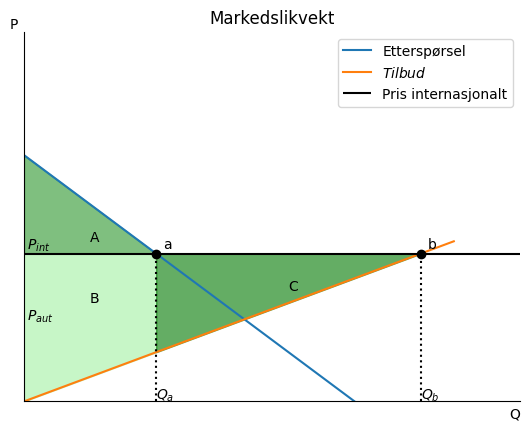

In [160]:
# Figur 9.4a
fig, ax = create_ax()
P_verdier = np.linspace(0, 1.3, 100)

# Fjerner tallverdier
ax.set_xticks([])
ax.set_yticks([])

# Etterspørselskurve
ax.plot(1 - P_verdier, P_verdier, label='Etterspørsel')

# Tilbudskurve
ax.plot(-gamma_verdi+ P_verdier, P_verdier/2, label='$Tilbud$')

# Pris internasjonalt
ax.hlines(0.6, 0, 1.5, color='black', label='Pris internasjonalt')
ax.annotate('$P_{int}$', (0.01, 0.62))

# Likevektspunkt a
ax.scatter(0.4, 0.6, color='black', zorder=5)
ax.annotate('a', (0.42, 0.62))

# Likevektspunkt b
ax.scatter(1.2, 0.6, color='black', zorder=5)
ax.annotate('b', (1.22, 0.62))

# Pris autarki
#ax.hlines(0.33, 0, 1.5, color='grey', label='Pris autarki')
ax.annotate('$P_{aut}$', (0.01, 0.33))

# Tittel
ax.set_title('Markedslikvekt')

# Fyller inn områdene
P_1 = np.linspace(0,0.4,100)
P_2 = np.linspace(0.4,1.2,100)
# Areal A
ax.fill_between(P_1, 1 - P_1, 0.6, color='green', alpha=0.5)
ax.annotate('A', (0.2, 0.65))
# Areal B
ax.fill_between(P_1, 0.6, P_1/2, color='lightgreen', alpha=0.5)
ax.annotate('B', (0.2, 0.4))
# Areal C
ax.fill_between(P_2, 0.6, P_2/2, color='forestgreen', alpha= 0.7)
ax.annotate('C', (0.8, 0.45))

# Kvantum a
ax.vlines(0.4, 0, 0.6, linestyles="dotted", color="black")
ax.annotate('$Q_{a}$', (0.4, 0.01))
#Kvantum b
ax.vlines(1.2, 0, 0.6, linestyles ="dotted", color='black')
ax.annotate('$Q_{b}$', (1.2, 0.01))

ax.legend();


**b.** Diskuter så konsekvensene av en lavprispolitikk, hvor vi ser for oss at myndighetene kontrollerer produksjon av olje og salget av bensin og hvor prisen i Norge settes lik grensekostnaden (i praksis lik autarkiprisen). Hva blir markedslikevekten, og hva er konsekvensene for konsumentoverskudd, produsentoverskudd og samfunnsøkonomisk effektivitet, sammenlignet med frihandels-scenariet i deloppgave a?




Med internasjonal handel så vil den internasjonale prisen $P_{int}$ også være gjeldene i Norge. For at et land skal skal eksportere en vare, så må $P_{int} > P_{aut}$ hvor $P_{aut}$ er prisen i autarki (uten handel).

Figuren nedenfor illustrerer et slikt eksempel. Konsumenttilpasningen blir i punkt $a$, hvor etterspørselkurven krysser den internasjonale prisen. Produsentene vil dermed selge et kvantum $Q_a$ til norske konsumenter, mens resten av produksjonen går til eksport: $Q_{exp} = Q_b - Q_a$.

Konsumentoverskuddet er her vist som areal $A$, mens produsentoverskuddet er areal $BC$, slik at det samfunnsøkonomiske overskuddet er areal $ABC$.

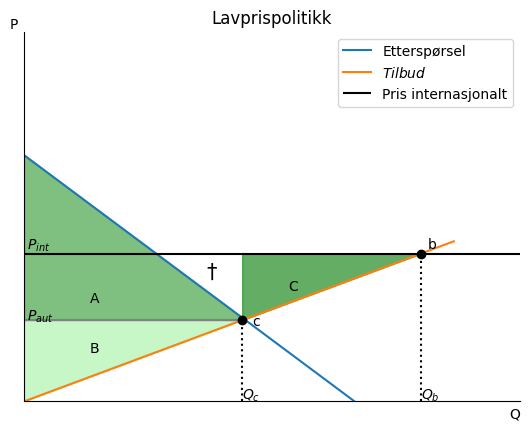

In [161]:
# Figur 9.4b
fig, ax = create_ax()
P_verdier = np.linspace(0, 1.3, 100)

# Fjerner tallverdier
ax.set_xticks([])
ax.set_yticks([])

# Etterspørselskurve
ax.plot(1 - P_verdier, P_verdier, label='Etterspørsel')

# Tilbudskurve
ax.plot(-gamma_verdi+ P_verdier, P_verdier/2, label='$Tilbud$')

# Pris internasjonalt
ax.hlines(0.6, 0, 1.5, color='black', label='Pris internasjonalt')
ax.annotate('$P_{int}$', (0.01, 0.62))

# Likevektspunkt b
ax.scatter(1.2, 0.6, color='black', zorder=5)
ax.annotate('b', (1.22, 0.62))

# Likevektspunkt c
ax.scatter(0.66, 0.33, color='black', zorder=5)
ax.annotate('c', (0.69, 0.31))

# Pris autarki
ax.hlines(0.33, 0, 0.67, color='grey')
ax.annotate('$P_{aut}$', (0.01, 0.33))

#Kvantum b
ax.vlines(1.2, 0, 0.6, linestyles ="dotted", color='black')
ax.annotate('$Q_{b}$', (1.2, 0.01))
# Kvantum c
ax.vlines(0.66, 0, 0.33, linestyles="dotted", color="black")
ax.annotate('$Q_{c}$', (0.66, 0.01))

# Fyller inn områdene
P_1 = np.linspace(0,0.66,100)
P_2 = np.linspace(0.66,1.2,100)

# Areal A
ax.fill_between(P_1, 1 - P_1, 0.33, color='green', alpha=0.5)
ax.annotate('A', (0.2, 0.4))

# Areal B
ax.fill_between(P_1, 0.33, P_1/2, color='lightgreen', alpha=0.5)
ax.annotate('B', (0.2, 0.2))

# Areal C
ax.fill_between(P_2, 0.6, P_2/2, color='forestgreen', alpha= 0.7)
ax.annotate('C', (0.8, 0.45))

# Setter inn symbol for dødvektstap
ax.annotate(r'$\dagger$', (0.55, 0.5), fontsize=15, color='black')

# Tittel
ax.set_title('Lavprispolitikk')

ax.legend();

Lavprispolitikken gjør at norske forbrukere bare må betale grensekostnaden, som gjør at norske konsumenter vil tilpasse seg i punkt $c$, som i autarki. Total produksjon vil fremdeles være gitt ved $Q_b$, hvor grensekostnadene er lik den internasjonale prisen.

Mengde solgt i Norge blir da gitt ved $Q_c$, og resten av produksjonen går til eksport: $Q_{exp} = Q_b - Q_c$. Vi legger merke til at lavprispolitikken gir lavere eksport, siden mer av den samlede produksjonen går til å dekke etterspørselen i Norge.

Når vi sammenligner figurene ser vi at konsumentoverskuddet har økt betydelig som følge av denne politikken (større areal A), samtidig som produsentoverskuddet har skrumpet inn (mindre areal areal BC). Vi ser også at lavprispolitikken har gitt et dødvektstap $\dagger$. 

Dette skyldes at vi selger olje til norske kunder med betalingsvilje lavere enn den internasjonale prisen: et tapt produsentoverskudd som ikke motsvares av en tilsvarende gevinst for konsumentene.


Her er det noen ekstra konsepter for de som er interesserte. 

[https://no.wikipedia.org/wiki/Baumol-effekten](https://no.wikipedia.org/wiki/Baumol-effekten)

[https://no.wikipedia.org/wiki/Hollandsk_syke](https://no.wikipedia.org/wiki/Hollandsk_syke)

## 9.5 Når den usynlige hånd svikter: Dødvektstapet ved forurensning. Frivillig oppgave

Se på figur 9.4 i hovedboken. Anta at etterspørselen er gitt ved $Q^E = 5 - P$ og tilbudet ved $Q^T = -1 + 2P$. Det er en miljøkostnad $m = 1.5$ per enhet produsert.

**a.** Hva er pris og mengde i markedslikevekten $a$ og den samfunnsøkonomisk optimale løsningen $b$?

**b.** Hvor stort er dødvektstapet $(\dagger)$ i markedslikevekten?
